In [9]:
import os
import joblib
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_auc_score, f1_score, accuracy_score, precision_score, recall_score, brier_score_loss
from sklearn.calibration import calibration_curve
from sklearn.tree import DecisionTreeClassifier

In [10]:
def train_logistic_regression(data_dir="../data/processed", model_dir="../models"):
    print("--- Phase 3: Training Logistic Regression Baseline ---")
    
    # Load processed data
    X_train = pd.read_csv(os.path.join(data_dir, "X_train.csv"))
    y_train = pd.read_csv(os.path.join(data_dir, "y_train.csv")).values.ravel()
    X_val = pd.read_csv(os.path.join(data_dir, "X_val.csv"))
    y_val = pd.read_csv(os.path.join(data_dir, "y_val.csv")).values.ravel()

    # Define hyperparameter space (liblinear supports both L1 and L2)
    param_grid = {
        'C': [0.001, 0.01, 0.1, 1, 10, 100],
        'penalty': ['l1', 'l2']
    }
    
    base_lr = LogisticRegression(solver='liblinear', random_state=42, max_iter=1000)
    
    # 5-Fold Stratified Cross-Validation
    grid_search = GridSearchCV(base_lr, param_grid, cv=5, scoring='roc_auc', n_jobs=-1)
    grid_search.fit(X_train, y_train)
    
    best_lr = grid_search.best_estimator_
    print(f"Best Hyperparameters: {grid_search.best_params_}")

    # Predict probabilities and hard labels on Validation set
    y_val_probs = best_lr.predict_proba(X_val)[:, 1]
    y_val_preds = best_lr.predict(X_val)

    # Calculate Evaluation Metrics
    auc = roc_auc_score(y_val, y_val_probs)
    f1 = f1_score(y_val, y_val_preds)
    acc = accuracy_score(y_val, y_val_preds)
    prec = precision_score(y_val, y_val_preds)
    rec = recall_score(y_val, y_val_preds)
    brier = brier_score_loss(y_val, y_val_probs)

    print("\nValidation Metrics:")
    print(f"  AUC-ROC:        {auc:.4f}")
    print(f"  F1-Score:       {f1:.4f}")
    print(f"  Accuracy:       {acc:.4f}")
    print(f"  Precision:      {prec:.4f}")
    print(f"  Recall (Sens):  {rec:.4f}")
    print(f"  Brier Score:    {brier:.4f} (Calibration Quality)")

    # Extract Coefficients and Calculate Odds Ratios for Global Interpretability
    coefficients = best_lr.coef_[0]
    odds_ratios = np.exp(coefficients)
    
    features_df = pd.DataFrame({
        'Feature': X_train.columns,
        'Coefficient': coefficients,
        'Odds_Ratio': odds_ratios
    }).sort_values(by='Odds_Ratio', ascending=False)

    print("\nTop 5 Features Increasing Readmission Risk (Odds Ratio > 1):")
    print(features_df.head(5).to_string(index=False))
    print("\nTop 5 Features Decreasing Readmission Risk (Odds Ratio < 1):")
    print(features_df.tail(5).to_string(index=False))

    # Save Model Artifact
    os.makedirs(model_dir, exist_ok=True)
    model_path = os.path.join(model_dir, "logistic_regression.pkl")
    joblib.dump(best_lr, model_path)
    print(f"\nModel artifact serialized to: {model_path}\n")

In [11]:
train_logistic_regression()

--- Phase 3: Training Logistic Regression Baseline ---
Best Hyperparameters: {'C': 100, 'penalty': 'l2'}

Validation Metrics:
  AUC-ROC:        0.6075
  F1-Score:       0.1972
  Accuracy:       0.5969
  Precision:      0.1195
  Recall (Sens):  0.5625
  Brier Score:    0.2350 (Calibration Quality)

Top 5 Features Increasing Readmission Risk (Odds Ratio > 1):
                               Feature  Coefficient  Odds_Ratio
              glyburide-metformin_Down     6.733467  840.054742
medical_specialty_Cardiology-Pediatric     3.654048   38.630724
            medical_specialty_Oncology     2.922656   18.590597
 medical_specialty_Hematology/Oncology     2.780849   16.132714
     medical_specialty_Surgery-Plastic     2.704132   14.941349

Top 5 Features Decreasing Readmission Risk (Odds Ratio < 1):
                                   Feature  Coefficient  Odds_Ratio
                        tolbutamide_Steady    -4.141092    0.015905
              medical_specialty_Gynecology    -4.238275   

In [13]:
def train_decision_tree(data_dir="../data/processed", model_dir="../models"):
    print("--- Phase 3: Training Decision Tree Baseline ---")
    
    # Load processed data
    X_train = pd.read_csv(os.path.join(data_dir, "X_train.csv"))
    y_train = pd.read_csv(os.path.join(data_dir, "y_train.csv")).values.ravel()
    X_val = pd.read_csv(os.path.join(data_dir, "X_val.csv"))
    y_val = pd.read_csv(os.path.join(data_dir, "y_val.csv")).values.ravel()

    # Define hyperparameter space constraining depth for strict transparency
    param_grid = {
        'max_depth': [4, 5, 6, 7, 8],
        'criterion': ['gini', 'entropy'],
        'min_samples_split': [10, 20, 50]
    }
    
    base_dt = DecisionTreeClassifier(random_state=42)
    
    # 5-Fold Stratified Cross-Validation
    grid_search = GridSearchCV(base_dt, param_grid, cv=5, scoring='roc_auc', n_jobs=-1)
    grid_search.fit(X_train, y_train)
    
    best_dt = grid_search.best_estimator_
    print(f"Best Hyperparameters: {grid_search.best_params_}")

    # Predict probabilities and hard labels on Validation set
    y_val_probs = best_dt.predict_proba(X_val)[:, 1]
    y_val_preds = best_dt.predict(X_val)

    # Calculate Evaluation Metrics
    auc = roc_auc_score(y_val, y_val_probs)
    f1 = f1_score(y_val, y_val_preds)
    acc = accuracy_score(y_val, y_val_preds)
    prec = precision_score(y_val, y_val_preds)
    rec = recall_score(y_val, y_val_preds)
    brier = brier_score_loss(y_val, y_val_probs)

    print("\nValidation Metrics:")
    print(f"  AUC-ROC:        {auc:.4f}")
    print(f"  F1-Score:       {f1:.4f}")
    print(f"  Accuracy:       {acc:.4f}")
    print(f"  Precision:      {prec:.4f}")
    print(f"  Recall (Sens):  {rec:.4f}")
    print(f"  Brier Score:    {brier:.4f}")

    # Global Feature Importance Analysis
    importances = best_dt.feature_importances_
    features_df = pd.DataFrame({
        'Feature': X_train.columns,
        'Gini_Importance': importances
    }).sort_values(by='Gini_Importance', ascending=False)

    print("\nTop 5 Most Informative Splits (Gini Importance):")
    print(features_df.head(5).to_string(index=False))

    # Save Model Artifact
    os.makedirs(model_dir, exist_ok=True)
    model_path = os.path.join(model_dir, "decision_tree.pkl")
    joblib.dump(best_dt, model_path)
    print(f"\nModel artifact serialized to: {model_path}\n")

In [14]:
train_decision_tree()

--- Phase 3: Training Decision Tree Baseline ---
Best Hyperparameters: {'criterion': 'entropy', 'max_depth': 8, 'min_samples_split': 50}

Validation Metrics:
  AUC-ROC:        0.5906
  F1-Score:       0.0815
  Accuracy:       0.9097
  Precision:      0.3874
  Recall (Sens):  0.0456
  Brier Score:    0.1020

Top 5 Most Informative Splits (Gini Importance):
                 Feature  Gini_Importance
discharge_disposition_id         0.510657
diag_1_group_Circulatory         0.138409
        time_in_hospital         0.076405
             age_[50-60)         0.054532
diag_2_group_Circulatory         0.048973

Model artifact serialized to: ../models/decision_tree.pkl



In [15]:
import os
import joblib
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_auc_score, f1_score, accuracy_score, precision_score, recall_score, brier_score_loss

def train_random_forest(data_dir="../data/processed", model_dir="../models"):
    print("--- Phase 4: Training Random Forest Ensemble ---")
    
    # Load processed data
    X_train = pd.read_csv(os.path.join(data_dir, "X_train.csv"))
    y_train = pd.read_csv(os.path.join(data_dir, "y_train.csv")).values.ravel()
    X_val = pd.read_csv(os.path.join(data_dir, "X_val.csv"))
    y_val = pd.read_csv(os.path.join(data_dir, "y_val.csv")).values.ravel()

    # Hyperparameter grid to control overfitting while allowing non-linear captures
    param_grid = {
        'n_estimators': [100, 200],
        'max_depth': [10, 15, 20],
        'min_samples_split': [5, 10],
        'max_features': ['sqrt', 'log2']
    }
    
    # Use class_weight='balanced_subsample' to provide additional stabilization on bootstrap splits
    base_rf = RandomForestClassifier(random_state=42, class_weight='balanced', n_jobs=-1)
    
    grid_search = GridSearchCV(base_rf, param_grid, cv=5, scoring='roc_auc', n_jobs=-1)
    grid_search.fit(X_train, y_train)
    
    best_rf = grid_search.best_estimator_
    print(f"Best Hyperparameters: {grid_search.best_params_}")

    # Evaluations
    y_val_probs = best_rf.predict_proba(X_val)[:, 1]
    y_val_preds = best_rf.predict(X_val)

    print("\nValidation Metrics:")
    print(f"  AUC-ROC:        {roc_auc_score(y_val, y_val_probs):.4f}")
    print(f"  F1-Score:       {f1_score(y_val, y_val_preds):.4f}")
    print(f"  Accuracy:       {accuracy_score(y_val, y_val_preds):.4f}")
    print(f"  Precision:      {precision_score(y_val, y_val_preds):.4f}")
    print(f"  Recall (Sens):  {recall_score(y_val, y_val_preds):.4f}")
    print(f"  Brier Score:    {brier_score_loss(y_val, y_val_probs):.4f}")

    # Feature Importance (MDI)
    importances = best_rf.feature_importances_
    features_df = pd.DataFrame({
        'Feature': X_train.columns,
        'Importance': importances
    }).sort_values(by='Importance', ascending=False)

    print("\nTop 5 Gini Importance Features:")
    print(features_df.head(5).to_string(index=False))

    # Serialize
    os.makedirs(model_dir, exist_ok=True)
    model_path = os.path.join(model_dir, "random_forest.pkl")
    joblib.dump(best_rf, model_path)
    print(f"\nModel artifact serialized to: {model_path}\n")

In [16]:
train_random_forest()

--- Phase 4: Training Random Forest Ensemble ---
Best Hyperparameters: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_split': 5, 'n_estimators': 200}

Validation Metrics:
  AUC-ROC:        0.6228
  F1-Score:       0.0021
  Accuracy:       0.9119
  Precision:      0.3333
  Recall (Sens):  0.0011
  Brier Score:    0.0901

Top 5 Gini Importance Features:
                  Feature  Importance
 discharge_disposition_id    0.079183
         time_in_hospital    0.037206
              age_[70-80)    0.034094
       payer_code_Unknown    0.033626
medical_specialty_Unknown    0.030823

Model artifact serialized to: ../models/random_forest.pkl



In [21]:
import os
import joblib
import pandas as pd
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_auc_score, f1_score, accuracy_score, precision_score, recall_score, brier_score_loss

def train_xgboost(data_dir="../data/processed", model_dir="../models"):
    print("--- Phase 4: Training XGBoost Production Ensemble ---")
    
    # Load processed data
    X_train = pd.read_csv(os.path.join(data_dir, "X_train.csv"))
    y_train = pd.read_csv(os.path.join(data_dir, "y_train.csv")).values.ravel()
    X_val = pd.read_csv(os.path.join(data_dir, "X_val.csv"))
    y_val = pd.read_csv(os.path.join(data_dir, "y_val.csv")).values.ravel()

    # Replaces brackets with underscores and comparison operators with text representations
    for df in [X_train, X_val]:
        df.columns = (df.columns
                      .str.replace('[', '_', regex=False)
                      .str.replace(']', '_', regex=False)
                      .str.replace('<', 'lt_', regex=False)
                      .str.replace('>', 'gt_', regex=False))

    # Hyperparameter tuning space targeting regularizations and learning rates
    param_grid = {
        'max_depth': [4, 6, 8],
        'learning_rate': [0.01, 0.1, 0.2],
        'n_estimators': [100, 200],
        'reg_alpha': [0.1, 1.0],  # L1 regularization
        'reg_lambda': [1.0, 5.0]  # L2 regularization
    }
    
    base_xgb = XGBClassifier(
        tree_method='hist', 
        random_state=42, 
        eval_metric='logloss',
        n_jobs=-1
    )
    
    grid_search = GridSearchCV(base_xgb, param_grid, cv=5, scoring='roc_auc', n_jobs=-1)
    grid_search.fit(X_train, y_train)
    best_xgb = grid_search.best_estimator_
    print(f"Best Hyperparameters: {grid_search.best_params_}")

    # Evaluations
    y_val_probs = best_xgb.predict_proba(X_val)[:, 1]
    y_val_preds = best_xgb.predict(X_val)

    print("\nValidation Metrics:")
    print(f"  AUC-ROC:        {roc_auc_score(y_val, y_val_probs):.4f}")
    print(f"  F1-Score:       {f1_score(y_val, y_val_preds):.4f}")
    print(f"  Accuracy:       {accuracy_score(y_val, y_val_preds):.4f}")
    print(f"  Precision:      {precision_score(y_val, y_val_preds):.4f}")
    print(f"  Recall (Sens):  {recall_score(y_val, y_val_preds):.4f}")
    print(f"  Brier Score:    {brier_score_loss(y_val, y_val_probs):.4f}")

    # Gain Feature Importance
    importances = best_xgb.feature_importances_
    features_df = pd.DataFrame({
        'Feature': X_train.columns,
        'Gain_Importance': importances
    }).sort_values(by='Gain_Importance', ascending=False)

    print("\nTop 5 Gain Importance Features:")
    print(features_df.head(5).to_string(index=False))

    # Serialize
    os.makedirs(model_dir, exist_ok=True)
    model_path = os.path.join(model_dir, "xgboost.pkl")
    joblib.dump(best_xgb, model_path)
    print(f"\nModel artifact serialized to: {model_path}\n")

In [22]:
train_xgboost()

--- Phase 4: Training XGBoost Production Ensemble ---
Best Hyperparameters: {'learning_rate': 0.1, 'max_depth': 8, 'n_estimators': 100, 'reg_alpha': 1.0, 'reg_lambda': 5.0}

Validation Metrics:
  AUC-ROC:        0.6540
  F1-Score:       0.0105
  Accuracy:       0.9121
  Precision:      0.5556
  Recall (Sens):  0.0053
  Brier Score:    0.0776

Top 5 Gain Importance Features:
                 Feature  Gain_Importance
discharge_disposition_id         0.072782
diag_1_group_Circulatory         0.056264
             age__70-80)         0.046731
diag_3_group_Circulatory         0.036351
             age__50-60)         0.035895

Model artifact serialized to: ../models/xgboost.pkl



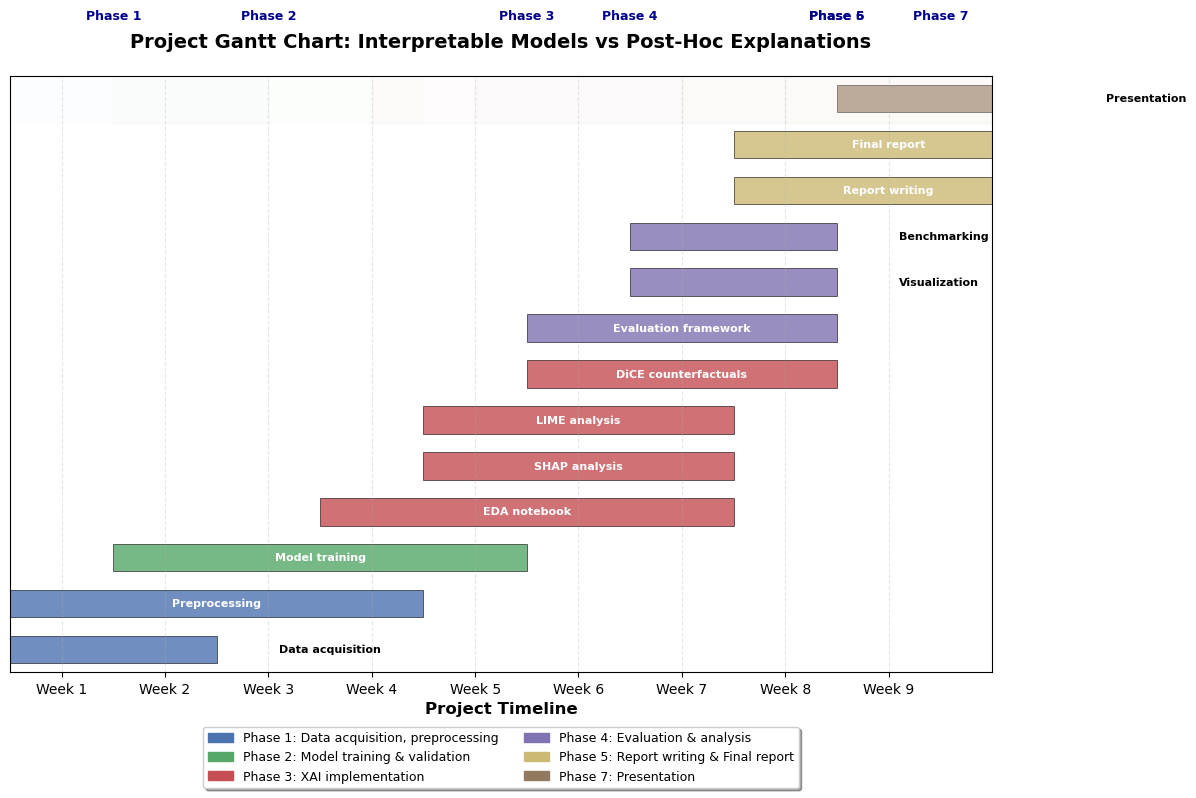

In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# Define the data
# Each task: (task_name, start_week, duration_weeks, color, phase)
tasks = [
    # Phase 1: Data acquisition, preprocessing
    ("Data acquisition", 1, 2, '#4C72B0', 'Phase 1'),
    ("Preprocessing", 1, 4, '#4C72B0', 'Phase 1'),
    
    # Phase 2: Model training & validation
    ("Model training", 2, 4, '#55A868', 'Phase 2'),
    
    # Phase 3: XAI implementation
    ("EDA notebook", 4, 4, '#C44E52', 'Phase 3'),
    ("SHAP analysis", 5, 3, '#C44E52', 'Phase 3'),
    ("LIME analysis", 5, 3, '#C44E52', 'Phase 3'),
    ("DiCE counterfactuals", 6, 3, '#C44E52', 'Phase 3'),
    
    # Phase 4: Evaluation & analysis
    ("Evaluation framework", 6, 3, '#8172B2', 'Phase 4'),
    ("Visualization", 7, 2, '#8172B2', 'Phase 4'),
    ("Benchmarking", 7, 2, '#8172B2', 'Phase 4'),
    
    # Phase 5-7: Report writing and presentation
    ("Report writing", 8, 3, '#CCB974', 'Phase 5'),
    ("Final report", 8, 3, '#CCB974', 'Phase 6'),
    ("Presentation", 9, 2, '#937860', 'Phase 7'),
]

# Create the figure and axis
fig, ax = plt.subplots(figsize=(12, 8))

# Plot each task as a horizontal bar
y_pos = np.arange(len(tasks))
for i, (task, start, duration, color, phase) in enumerate(tasks):
    ax.barh(i, duration, left=start-0.5, height=0.6, color=color, 
            edgecolor='black', linewidth=0.5, alpha=0.8)
    
    # Add task labels on the bars (for longer bars)
    if duration >= 3:
        ax.text(start + duration/2 - 0.5, i, task, 
                ha='center', va='center', fontsize=8, fontweight='bold', color='white')
    else:
        # For short bars, place label to the right
        ax.text(start + duration + 0.1, i, task, 
                ha='left', va='center', fontsize=8, fontweight='bold', color='black')

# Set the y-axis labels (task names removed as they're on the bars)
ax.set_yticks([])
ax.set_ylim(-0.5, len(tasks) - 0.5)

# Set x-axis
ax.set_xlim(0.5, 10)
ax.set_xticks(range(1, 10))
ax.set_xticklabels([f'Week {i}' for i in range(1, 10)])
ax.set_xlabel('Project Timeline', fontsize=12, fontweight='bold')

# Add gridlines
ax.grid(axis='x', alpha=0.3, linestyle='--')

# Add title
ax.set_title('Project Gantt Chart: Interpretable Models vs Post-Hoc Explanations', 
             fontsize=14, fontweight='bold', pad=20)

# Add phase labels as shaded background regions
phase_colors = {
    'Phase 1': '#E8F4F8',
    'Phase 2': '#E8F8E8',
    'Phase 3': '#FDE8E8',
    'Phase 4': '#EDE8F8',
    'Phase 5': '#F8F4E8',
    'Phase 6': '#F8F4E8',
    'Phase 7': '#F0EAE8'
}

# Get unique phases in order
phases = []
for _, _, _, _, phase in tasks:
    if phase not in phases:
        phases.append(phase)

# Add phase labels above the chart
phase_y = len(tasks) + 0.5
phase_x_positions = {
    'Phase 1': 1.5,
    'Phase 2': 3,
    'Phase 3': 5.5,
    'Phase 4': 6.5,
    'Phase 5': 8.5,
    'Phase 6': 8.5,
    'Phase 7': 9.5
}

for phase in phases:
    if phase in phase_x_positions:
        ax.axvspan(phase_x_positions[phase] - 1.5, phase_x_positions[phase] + 1.5, 
                   ymin=0.92, ymax=1.0, alpha=0.1, color=phase_colors.get(phase, 'gray'))
        ax.text(phase_x_positions[phase], phase_y + 0.3, phase.replace('Phase ', 'Phase '), 
                ha='center', va='center', fontsize=9, fontweight='bold', 
                rotation=0, color='darkblue')

# Add legend for phases
legend_patches = [
    mpatches.Patch(color='#4C72B0', label='Phase 1: Data acquisition, preprocessing'),
    mpatches.Patch(color='#55A868', label='Phase 2: Model training & validation'),
    mpatches.Patch(color='#C44E52', label='Phase 3: XAI implementation'),
    mpatches.Patch(color='#8172B2', label='Phase 4: Evaluation & analysis'),
    mpatches.Patch(color='#CCB974', label='Phase 5: Report writing & Final report'),
    mpatches.Patch(color='#937860', label='Phase 7: Presentation'),
]

# Place legend below the chart
ax.legend(handles=legend_patches, loc='upper center', bbox_to_anchor=(0.5, -0.08), 
          ncol=2, fontsize=9, frameon=True, fancybox=True, shadow=True)

# Adjust layout to prevent legend cutoff
plt.tight_layout()
plt.subplots_adjust(bottom=0.15)

# Save the figure
plt.savefig('gantt_chart.png', dpi=300, bbox_inches='tight')
plt.savefig('gantt_chart.pdf', bbox_inches='tight')

# Display the chart
plt.show()

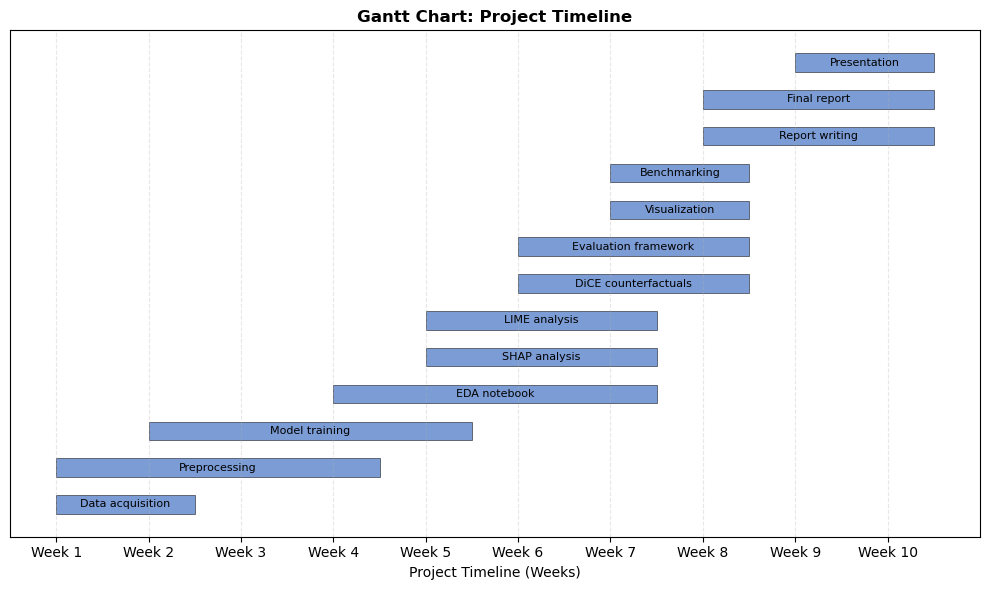

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# Simplified task data: (task_name, start_week, end_week)
tasks = [
    # Phase 1
    ("Data acquisition", 1, 2.5),
    ("Preprocessing", 1, 4.5),
    # Phase 2
    ("Model training", 2, 5.5),
    # Phase 3
    ("EDA notebook", 4, 7.5),
    ("SHAP analysis", 5, 7.5),
    ("LIME analysis", 5, 7.5),
    ("DiCE counterfactuals", 6, 8.5),
    # Phase 4
    ("Evaluation framework", 6, 8.5),
    ("Visualization", 7, 8.5),
    ("Benchmarking", 7, 8.5),
    # Phase 5-7
    ("Report writing", 8, 10.5),
    ("Final report", 8, 10.5),
    ("Presentation", 9, 10.5),
]

fig, ax = plt.subplots(figsize=(10, 6))

# Plot bars
for i, (task, start, end) in enumerate(tasks):
    ax.barh(i, end - start, left=start, height=0.5, 
            color='#4472C4', alpha=0.7, edgecolor='black', linewidth=0.5)
    ax.text(start + (end-start)/2, i, task, ha='center', va='center', fontsize=8)

# Formatting
ax.set_xlim(0.5, 11)
ax.set_xticks(range(1, 11))
ax.set_xticklabels([f'Week {i}' for i in range(1, 11)])
ax.set_yticks([])
ax.set_xlabel('Project Timeline (Weeks)')
ax.set_title('Gantt Chart: Project Timeline', fontweight='bold')
ax.grid(axis='x', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig('gantt_chart_simple.png', dpi=300, bbox_inches='tight')
plt.show()